# Produits complémentaires et panier moyen — Lumina & Co

Question : quels produits s'achètent ensemble, et lesquels ajouter pour faire monter le panier moyen ?

Méthode : une facture = un panier. On mesure le **lift** (les deux produits s'achètent plus souvent ensemble que si c'était le hasard). Lift > 1 = complémentaires. Les lignes `Frais` sont exclues.

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_DIR = Path("Lumina & Co - CRM")
tx = pd.read_csv(DATA_DIR / "transactions.csv")
tx = tx[tx["category"].ne("Frais") & tx["product_name"].notna()].copy()
tx["line_total"] = tx["quantity"] * tx["unit_price"].clip(lower=0)

catalogue = (
    tx.groupby(["category", "product_name"], as_index=False)
    .agg(prix_median=("unit_price", "median"), n_factures=("invoice_id", "nunique"))
    .sort_values(["category", "product_name"])
)
print(f"{tx['product_name'].nunique()} produits | {tx['invoice_id'].nunique():,} factures")
display(catalogue.round(2))

25 produits | 245,958 factures


,category,product_name,prix_median,n_factures
0,Accessoire,Brosse Corps Fibres Naturelles,15.90,41907
1,Accessoire,Trousse Voyage Rechargeable,13.90,47328
2,Accessoire,Éponge Konjac Charbon,6.50,43044
3,Bain,Bombe de Bain Effervescente Rose,6.90,34552
4,Bain,Huile de Bain Relaxante Camomille,16.49,44599
5,Bain,Sel de Bain Fleur de Sel Provence,11.90,39805
6,Cheveux,Après-Shampoing Solide Argan,12.90,33981
7,Cheveux,Huile Capillaire Ricin Bio,17.49,44427
8,Cheveux,Masque Cheveux Avocat,19.89,31792
9,Cheveux,Shampoing Solide Ortie,12.89,35639


#### Taille de panier et panier moyen

Taille de panier (nombre de produits distincts) :


,n_produits
count,245958.00
mean,4.06
std,4.58
min,1.00
25%,1.00
50%,3.00
75%,4.00
max,25.00


Paniers 1 produit : 25.8% → panier moyen 27 €
Paniers 2+ produits : 74.2% → panier moyen 268 €


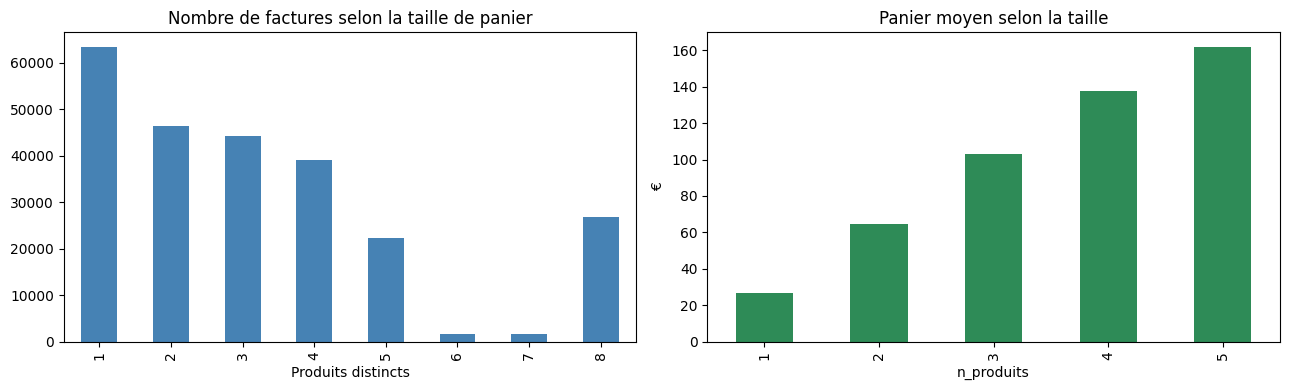

In [2]:
paniers = tx.groupby("invoice_id").agg(
    n_produits=("product_name", "nunique"),
    ca=("line_total", "sum"),
)
print("Taille de panier (nombre de produits distincts) :")
display(paniers["n_produits"].describe().to_frame("n_produits").round(2))
print(
    f"Paniers 1 produit : {(paniers['n_produits'] == 1).mean() * 100:.1f}% "
    f"→ panier moyen {paniers.loc[paniers['n_produits'] == 1, 'ca'].mean():.0f} €"
)
print(
    f"Paniers 2+ produits : {(paniers['n_produits'] >= 2).mean() * 100:.1f}% "
    f"→ panier moyen {paniers.loc[paniers['n_produits'] >= 2, 'ca'].mean():.0f} €"
)

aov_taille = (
    paniers[paniers["n_produits"] <= 5]
    .groupby("n_produits")["ca"].mean()
    .rename("panier_moyen")
)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
paniers["n_produits"].clip(upper=8).value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Nombre de factures selon la taille de panier")
axes[0].set_xlabel("Produits distincts")
aov_taille.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("Panier moyen selon la taille")
axes[1].set_ylabel("€")
plt.tight_layout()
plt.show()

#### Paires complémentaires (lift)

Lift = P(A et B) / (P(A)×P(B)). Au-dessus de 1, les deux produits s'attirent.

In [3]:
item_lists = tx.groupby("invoice_id")["product_name"].unique()
n = len(item_lists)
item_count = Counter()
pair_count = Counter()
for items in item_lists:
    items = sorted(set(items))
    for i in items:
        item_count[i] += 1
    for a, b in combinations(items, 2):
        pair_count[(a, b)] += 1

cat = tx.drop_duplicates("product_name").set_index("product_name")["category"]
prix = tx.groupby("product_name")["unit_price"].median()

pairs = pd.DataFrame(
    [
        {
            "produit_A": a,
            "produit_B": b,
            "co_achats": c,
            "lift": (c / n) / ((item_count[a] / n) * (item_count[b] / n)),
            "conf_A_vers_B": c / item_count[a],
            "conf_B_vers_A": c / item_count[b],
            "cat_A": cat[a],
            "cat_B": cat[b],
            "prix_A": prix[a],
            "prix_B": prix[b],
        }
        for (a, b), c in pair_count.items()
    ]
)

print("Top lift (co-achats ≥ 2 000) :")
top_lift = pairs[pairs["co_achats"] >= 2000].sort_values("lift", ascending=False)
display(top_lift.head(15).round(3))

print("Paires les plus fréquentes (volume) :")
display(pairs.sort_values("co_achats", ascending=False).head(12).round(3))

Top lift (co-achats ≥ 2 000) :


,produit_A,produit_B,co_achats,lift,conf_A_vers_B,conf_B_vers_A,cat_A,cat_B,prix_A,prix_B
101,Huile Démaquillante Camélia,Masque Cheveux Avocat,10291,2.492,0.322,0.324,Visage,Cheveux,22.88,19.89
169,Masque Cheveux Avocat,Shampoing Solide Ortie,11375,2.469,0.358,0.319,Cheveux,Cheveux,19.89,12.89
32,Après-Shampoing Solide Argan,Masque Cheveux Avocat,10830,2.466,0.319,0.341,Cheveux,Cheveux,12.90,19.89
29,Après-Shampoing Solide Argan,Huile Démaquillante Camélia,10786,2.444,0.317,0.338,Cheveux,Visage,12.90,22.88
138,Bombe de Bain Effervescente Rose,Masque Cheveux Avocat,10892,2.439,0.315,0.343,Bain,Cheveux,6.90,19.89
165,Masque Argile Verte Purifiant,Masque Cheveux Avocat,11466,2.432,0.314,0.361,Visage,Cheveux,19.50,19.89
188,Huile Démaquillante Camélia,Masque Argile Verte Purifiant,11469,2.421,0.359,0.314,Visage,Visage,22.88,19.50
81,Eau Micellaire Fleur d'Oranger,Masque Cheveux Avocat,11668,2.415,0.312,0.367,Visage,Cheveux,14.90,19.89
189,Huile Démaquillante Camélia,Shampoing Solide Ortie,11034,2.384,0.345,0.310,Visage,Cheveux,22.88,12.89
117,Après-Shampoing Solide Argan,Bombe de Bain Effervescente Rose,11372,2.382,0.335,0.329,Cheveux,Bain,12.90,6.90


Paires les plus fréquentes (volume) :


,produit_A,produit_B,co_achats,lift,conf_A_vers_B,conf_B_vers_A,cat_A,cat_B,prix_A,prix_B
9,Contour des Yeux Concombre,Trousse Voyage Rechargeable,17695,1.930,0.371,0.374,Visage,Accessoire,25.99,13.90
8,Contour des Yeux Concombre,Sérum Visage Bio Rose Musquée,17074,1.917,0.358,0.371,Visage,Visage,25.99,34.89
18,Sérum Visage Bio Rose Musquée,Trousse Voyage Rechargeable,17021,1.925,0.370,0.360,Visage,Accessoire,34.89,13.90
97,Huile Capillaire Ricin Bio,Trousse Voyage Rechargeable,16805,1.966,0.378,0.355,Cheveux,Accessoire,17.49,13.90
71,Contour des Yeux Concombre,Huile Capillaire Ricin Bio,16651,1.934,0.349,0.375,Visage,Cheveux,25.99,17.49
221,Huile Capillaire Ricin Bio,Sérum Visage Bio Rose Musquée,16561,1.995,0.373,0.360,Cheveux,Visage,17.49,34.89
74,Contour des Yeux Concombre,Huile de Bain Relaxante Camomille,16393,1.897,0.344,0.368,Visage,Bain,25.99,16.49
10,Contour des Yeux Concombre,Éponge Konjac Charbon,16381,1.964,0.344,0.381,Visage,Accessoire,25.99,6.50
112,Huile de Bain Relaxante Camomille,Trousse Voyage Rechargeable,16288,1.898,0.365,0.344,Bain,Accessoire,16.49,13.90
158,Crème Jour Karité Vanille,Trousse Voyage Rechargeable,16218,2.024,0.389,0.343,Visage,Accessoire,28.50,13.90


In [4]:
print("Complémentaires dans la même catégorie :")
intra = pairs.loc[pairs["cat_A"] == pairs["cat_B"]].copy()
intra = intra[intra["co_achats"] >= 2000].sort_values(["cat_A", "lift"], ascending=[True, False])
display(
    intra.groupby("cat_A", as_index=False)
    .head(3)[
        ["cat_A", "produit_A", "produit_B", "co_achats", "lift", "conf_A_vers_B", "prix_A", "prix_B"]
    ]
    .round(3)
)

Complémentaires dans la même catégorie :


,cat_A,produit_A,produit_B,co_achats,lift,conf_A_vers_B,prix_A,prix_B
235,Accessoire,Brosse Corps Fibres Naturelles,Éponge Konjac Charbon,15076,2.056,0.360,15.90,6.50
150,Accessoire,Brosse Corps Fibres Naturelles,Trousse Voyage Rechargeable,15864,1.967,0.379,15.90,13.90
20,Accessoire,Trousse Voyage Rechargeable,Éponge Konjac Charbon,16126,1.947,0.341,13.90,6.50
139,Bain,Bombe de Bain Effervescente Rose,Sel de Bain Fleur de Sel Provence,12242,2.189,0.354,6.90,11.90
136,Bain,Bombe de Bain Effervescente Rose,Huile de Bain Relaxante Camomille,13123,2.095,0.380,6.90,16.49
111,Bain,Huile de Bain Relaxante Camomille,Sel de Bain Fleur de Sel Provence,14705,2.037,0.330,16.49,11.90
169,Cheveux,Masque Cheveux Avocat,Shampoing Solide Ortie,11375,2.469,0.358,19.89,12.89
32,Cheveux,Après-Shampoing Solide Argan,Masque Cheveux Avocat,10830,2.466,0.319,12.90,19.89
121,Cheveux,Après-Shampoing Solide Argan,Shampoing Solide Ortie,11581,2.352,0.341,12.90,12.89
236,Coffret,Coffret Duo Visage Bio,Coffret Découverte Rituel Slow Beauty,13734,2.098,0.354,54.99,49.00


#### Lecture — produits complémentaires

Ce sont des **routines**, pas des hasards :

- **Cheveux** : Shampoing Solide Ortie + Après-Shampoing Argan + Masque Avocat (lift ~2,47). L'huile ricin se greffe sur ce trio.
- **Visage** : Eau Micellaire + Huile Démaquillante Camélia + Masque Argile (lift ~2,3–2,4). Routine démaquillage → soin.
- **Corps** : Déodorant Sauge + Savon Lavande + Lait Amande / Gommage Coco.
- **Bain** : Bombe Rose + Sel de Provence + Huile Camomille (rituel bain).
- **Accessoires** : Trousse Voyage + Éponge Konjac + Brosse Corps — ils voyagent avec le soin, surtout le contour des yeux et le sérum.

En **volume**, le hub du catalogue est **Contour des Yeux Concombre** + **Sérum Rose Musquée** + **Trousse Voyage** : c'est le panier « visage premium + accessoire » le plus vu.

#### Quoi ajouter pour augmenter le panier moyen

Add-ons pas chers (≤ 15 €) — facile à ajouter, volume :


,si_le_panier_a,ajouter,lift,probas,prix_ajout,gain_attendu,co_achats
18,Contour des Yeux Concombre,Trousse Voyage Rechargeable,1.930,0.371,13.90,5.161,17695
20,Contour des Yeux Concombre,Éponge Konjac Charbon,1.964,0.344,6.50,2.234,16381
12,Contour des Yeux Concombre,Savon Surgras Lavande,1.948,0.340,7.50,2.549,16194
89,Trousse Voyage Rechargeable,Baume Lèvres Cire d'Abeille,1.998,0.335,8.90,2.986,15878
33,Trousse Voyage Rechargeable,Sel de Bain Fleur de Sel Provence,1.992,0.322,11.90,3.836,15258
165,Trousse Voyage Rechargeable,Eau Micellaire Fleur d'Oranger,2.065,0.314,14.90,4.676,14854
549,Sérum Visage Bio Rose Musquée,Déodorant Solide Sauge,2.104,0.312,9.90,3.087,14333
343,Trousse Voyage Rechargeable,Shampoing Solide Ortie,2.037,0.295,12.89,3.804,13967


Add-ons chers (≥ 25 €) — levier panier moyen :


,si_le_panier_a,ajouter,lift,probas,prix_ajout,gain_attendu,co_achats
485,Masque Cheveux Avocat,Coffret Duo Visage Bio,2.370,0.374,54.99,20.542,11876
131,Masque Cheveux Avocat,Coffret Découverte Rituel Slow Beauty,2.283,0.386,49.00,18.893,12258
458,Masque Cheveux Avocat,Sérum Visage Bio Rose Musquée,2.284,0.427,34.89,14.889,13567
311,Masque Cheveux Avocat,Crème Jour Karité Vanille,2.306,0.390,28.50,11.128,12413
145,Huile Démaquillante Camélia,Contour des Yeux Concombre,2.159,0.418,25.99,10.872,13363


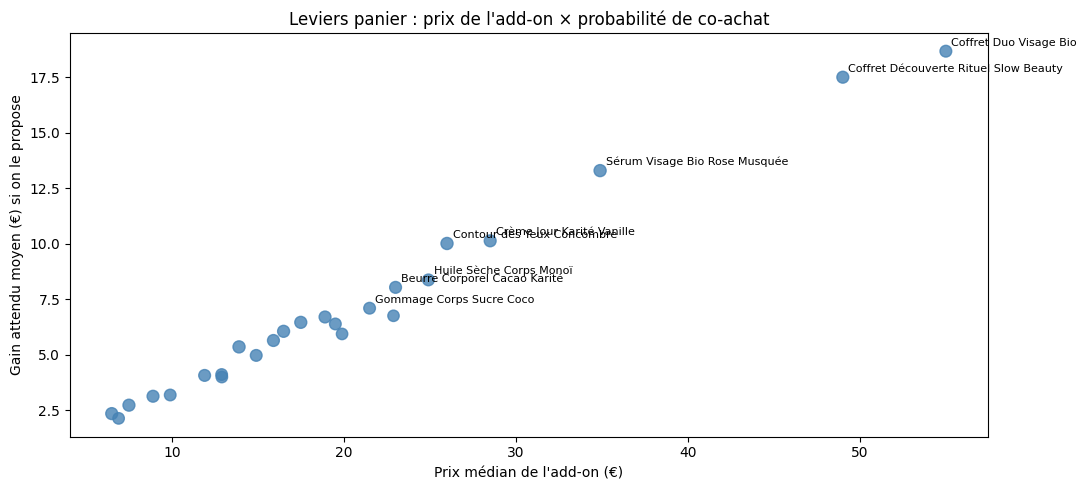

In [5]:
# Add-on : si le client a A, proposer B (confiance × prix de B = gain attendu brut)
addons = []
for _, r in pairs.iterrows():
    addons.append(
        {
            "si_le_panier_a": r["produit_A"],
            "ajouter": r["produit_B"],
            "lift": r["lift"],
            "probas": r["conf_A_vers_B"],
            "prix_ajout": r["prix_B"],
            "gain_attendu": r["conf_A_vers_B"] * r["prix_B"],
            "co_achats": r["co_achats"],
        }
    )
    addons.append(
        {
            "si_le_panier_a": r["produit_B"],
            "ajouter": r["produit_A"],
            "lift": r["lift"],
            "probas": r["conf_B_vers_A"],
            "prix_ajout": r["prix_A"],
            "gain_attendu": r["conf_B_vers_A"] * r["prix_A"],
            "co_achats": r["co_achats"],
        }
    )
recos = pd.DataFrame(addons)
recos = recos[recos["co_achats"] >= 2000]

print("Add-ons pas chers (≤ 15 €) — facile à ajouter, volume :")
cheap = recos[recos["prix_ajout"] <= 15].sort_values("co_achats", ascending=False)
display(cheap.drop_duplicates("ajouter").head(8).round(3))

print("Add-ons chers (≥ 25 €) — levier panier moyen :")
premium = recos[recos["prix_ajout"] >= 25].sort_values("gain_attendu", ascending=False)
display(premium.drop_duplicates("ajouter").head(8).round(3))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = (
    recos.groupby("ajouter", as_index=False)
    .agg(prix=("prix_ajout", "first"), gain=("gain_attendu", "mean"), co=("co_achats", "sum"))
)
ax.scatter(plot_df["prix"], plot_df["gain"], s=np.sqrt(plot_df["co"]) / 8, color="steelblue", alpha=0.8)
for _, r in plot_df.nlargest(8, "gain").iterrows():
    ax.annotate(r["ajouter"], (r["prix"], r["gain"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("Prix médian de l'add-on (€)")
ax.set_ylabel("Gain attendu moyen (€) si on le propose")
ax.set_title("Leviers panier : prix de l'add-on × probabilité de co-achat")
plt.tight_layout()
plt.show()

#### Recommandations

**Levier n°1 : sortir du panier à 1 produit.** 26 % des factures n'ont qu'un article (~27 €). Dès 2 produits, le panier moyen passe à ~65 €, et à ~268 € sur l'ensemble des paniers 2+.

**À ajouter pour convertir (petit prix, souvent ensemble) :**
- Éponge Konjac Charbon (~6,50 €) avec le contour des yeux / le sérum
- Bombe de Bain Rose (~6,90 €) et Savon Surgras Lavande (~7,50 €)
- Baume Lèvres (~8,90 €) et Déodorant Solide Sauge (~9,90 €)
- Trousse Voyage (~13,90 €) : c'est l'accessoire le plus co-acheté du catalogue

**À ajouter pour faire monter le ticket (prix haut, lift encore bon) :**
- Sérum Visage Bio Rose Musquée (~35 €) à côté du contour des yeux
- Crème Jour Karité Vanille (~28,50 €) dans la routine visage
- Coffret Duo Visage Bio (~55 €) et Coffret Découverte (~49 €) — upsell coffret plutôt que 2 SKU isolés
- Huile Sèche Corps Monoï / Beurre Cacao (~23–25 €) si le panier est déjà corps ou bain

**Bundles naturels (à mettre en « souvent achetés ensemble ») :**
1. Routine cheveux : shampoing + après-shampoing + masque avocat
2. Routine visage : micellaire + huile démaquillante + masque argile, puis sérum
3. Visage premium + accessoire : contour des yeux + sérum + trousse (ou éponge)
4. Rituel bain : bombe + sel + huile camomille

Ne pas juger un add-on seulement à son lift : un produit à 7 € avec beaucoup de co-achats **débloque** le 2e article ; un sérum à 35 € **gonfle** le panier une fois que le client a déjà dit oui.

#### Comment lire le lift (ex. Masque Cheveux Avocat × Coffret Duo Visage Bio = 2,370)

Le **2,370 n'est pas un pourcentage**. Ce n'est pas « 2,37 % de chance d'acheter B si on achète A ».

C'est un **multiplicateur** : les deux produits s'achètent **2,37 fois plus souvent ensemble** que si A et B n'avaient aucun lien.

La vraie proba, c'est la **confiance** :

- si le panier a le **Coffret Duo** → environ **31 %** d'avoir aussi le masque
- si le panier a le **Masque Avocat** → environ **37 %** d'avoir aussi le coffret

Le lift compare ça au hasard. Si le masque est dans ~13 % de tous les paniers, au hasard on attendrait ~13 % chez ceux qui ont le coffret. On en voit ~31 %, et 31 / 13 ≈ **2,37**.

En une phrase : lift = **combien de fois plus souvent que le hasard** ; confiance = **la vraie % de chance**.
